In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv("telecom_churn.csv")

In [3]:
dataset

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243548,243549,Airtel,F,28,Mizoram,Kolkata,110295,2023-05-03,3,130580,28,9,4102,0
243549,243550,Reliance Jio,F,52,Assam,Kolkata,713481,2023-05-03,0,82393,80,45,7521,0
243550,243551,Reliance Jio,M,59,Tripura,Kolkata,520218,2023-05-03,4,51298,26,4,6547,0
243551,243552,BSNL,M,49,Madhya Pradesh,Kolkata,387744,2023-05-03,2,83981,80,15,1125,0


In [4]:
#dataset.drop('customer_id','pincode',inplace=True,axis=1)
dataset.drop(['customer_id', 'pincode'], axis=1, inplace=True)

In [5]:
dataset.cov(numeric_only=True)

,age,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
age,270.406102,0.034006,-1.913788e+03,-0.677545,-0.665932,3.683108e+01,0.005525
num_dependents,0.034006,2.002059,1.144572e+02,0.013559,0.044330,1.322493e+01,-0.001441
estimated_salary,-1913.787604,114.457200,1.406922e+09,-171.826288,1503.188973,-3.733617e+05,-50.041569
calls_made,-0.677545,0.013559,-1.718263e+02,867.511972,0.014992,9.703865e+01,0.019955
sms_sent,-0.665932,0.044330,1.503189e+03,0.014992,217.078222,-1.247552e+02,-0.018120
data_used,36.831078,13.224931,-3.733617e+05,97.038653,-124.755216,8.655479e+06,0.861955
churn,0.005525,-0.001441,-5.004157e+01,0.019955,-0.018120,8.619553e-01,0.160287


In [6]:
dataset.corr(numeric_only=True)

,age,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
age,1.000000,0.001462,-0.003103,-0.001399,-0.002749,0.000761,0.000839
num_dependents,0.001462,1.000000,0.002157,0.000325,0.002126,0.003177,-0.002543
estimated_salary,-0.003103,0.002157,1.000000,-0.000156,0.002720,-0.003383,-0.003332
calls_made,-0.001399,0.000325,-0.000156,1.000000,0.000035,0.001120,0.001692
sms_sent,-0.002749,0.002126,0.002720,0.000035,1.000000,-0.002878,-0.003072
data_used,0.000761,0.003177,-0.003383,0.001120,-0.002878,1.000000,0.000732
churn,0.000839,-0.002543,-0.003332,0.001692,-0.003072,0.000732,1.000000


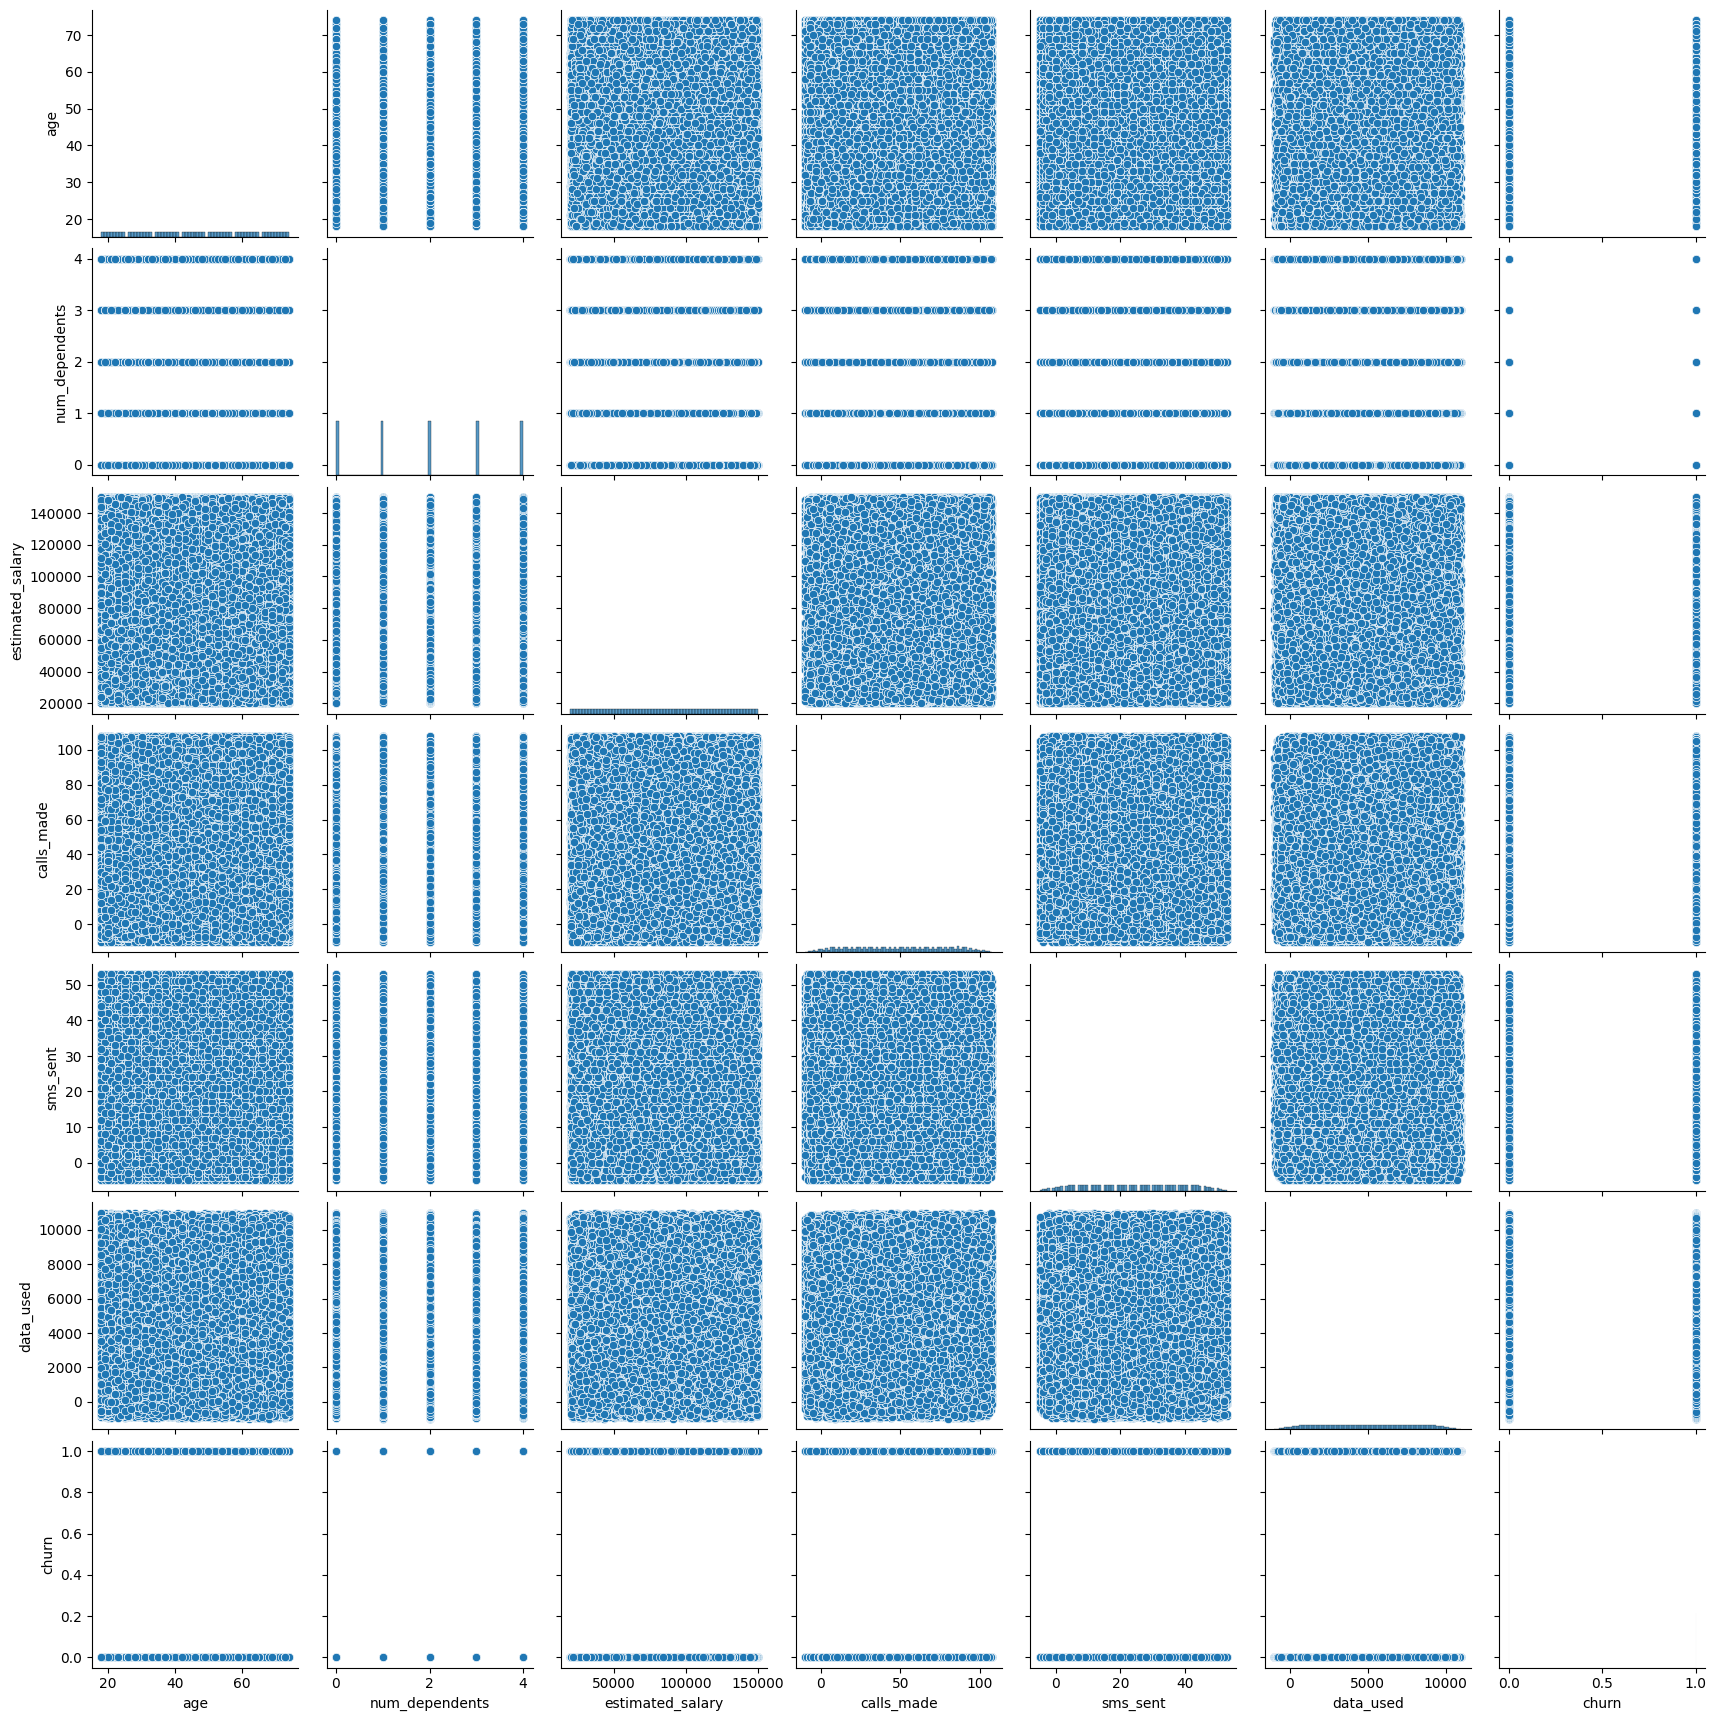

In [7]:
import seaborn as sns
sns.pairplot(dataset)

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [9]:
def calc_vif(X):
    vif=pd.DataFrame()
    vif["variables"]=X.columns
    vif["VIF"]=[variance_inflation_factor(X.values,i) for i in range (X.shape[1])]
    return (vif)

In [10]:
calc_vif(dataset[['age', 'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used', 'churn']])

,variables,VIF
0,age,6.002694
1,num_dependents,2.756123
2,estimated_salary,4.844411
3,calls_made,3.343654
4,sms_sent,3.247633
5,data_used,3.423746
6,churn,1.237521


In [ ]:
calc_vif(dataset[['num_dependents',  'churn']])

In [ ]:
calc_vif(dataset[['age', 'churn']])

In [ ]:
dataset[['age', 'churn']].corr()

In [11]:
dataset.groupby('telecom_partner')['estimated_salary'].mean()

telecom_partner
Airtel          85142.129316
BSNL            84931.258403
Reliance Jio    84976.637142
Vodafone        85034.439689
Name: estimated_salary, dtype: float64

In [12]:
from scipy.stats import ttest_ind
dataset=dataset.dropna()
male=dataset[dataset['gender']=='M']['estimated_salary']
female=dataset[dataset['gender']=='F']['estimated_salary']
ttest_ind(male,female)

TtestResult(statistic=np.float64(-1.1846809076397775), pvalue=np.float64(0.23614479004841119), df=np.float64(243551.0))

In [ ]:
# P<0.05
# P = 0.23
# p = 0.23 < 0.05 - False (Accept null htpothesis and Reject Alternate Hypothesis)

In [13]:
from scipy.stats import ttest_ind
tp=dataset[dataset['telecom_partner']=='Reliance Jio']['estimated_salary']
tp1=dataset[dataset['telecom_partner']=='Airtel']['estimated_salary']
ttest_ind(tp,tp1)

TtestResult(statistic=np.float64(-0.7698675737574336), pvalue=np.float64(0.4413799408477565), df=np.float64(122026.0))

In [ ]:
# P<0.05
# P = 0.44
# p = 0.44 < 0.05 - False (Accept null htpothesis and Reject Alternate Hypothesis)

In [25]:
#one way classification
import scipy.stats as stats
stats.f_oneway(dataset[dataset['churn'] == 0]['age'],dataset[dataset['churn'] == 1]['age'])

F_onewayResult(statistic=np.float64(0.17151484512153134), pvalue=np.float64(0.67876937588875))

In [40]:
stats.f_oneway(
    dataset[dataset['city'] == 'Kolkata']['churn'],
    dataset[dataset['city'] == 'Mumbai']['churn'],
    dataset[dataset['city'] == 'Delhi']['churn'],
    dataset[dataset['city'] == 'Chennai']['churn'],
    dataset[dataset['city'] == 'Hyderabad']['churn'],
    dataset[dataset['city'] == 'Bangalore']['churn'] 
)

F_onewayResult(statistic=np.float64(1.6947240293865022), pvalue=np.float64(0.13199765405177416))

In [ ]:
p-value < 0.05 → significant difference  = p-value = 0.13 < 0.05 False
p-value > 0.05 → no significant difference

In [27]:
#two way classification
import statsmodels.api as sm
from statsmodels.formula.api import ols
model = ols('churn ~ C(num_dependents) + age', data=dataset).fit()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
C(num_dependents),0.524987,4.0,0.818818,0.512861
age,0.028508,1.0,0.177852,0.673226
Residual,39037.711891,243547.0,NaN,NaN


In [ ]:
# p-value = 0.512 (> 0.05)
# NOT significant

# p-value = 0.673 (> 0.05)
# NOT significant

In [28]:
import statsmodels.formula.api as smf

model = smf.logit('churn ~ C(num_dependents) + age', data=dataset).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.501057
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:               243553
Model:                          Logit   Df Residuals:                   243547
Method:                           MLE   Df Model:                            5
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:               1.413e-05
Time:                        16:17:52   Log-Likelihood:            -1.2203e+05
converged:                       True   LL-Null:                   -1.2204e+05
Covariance Type:            nonrobust   LLR p-value:                    0.6311
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -1.3777      0.018    -76.160      0.000      -1.413      

<Axes: xlabel='age', ylabel='Count'>

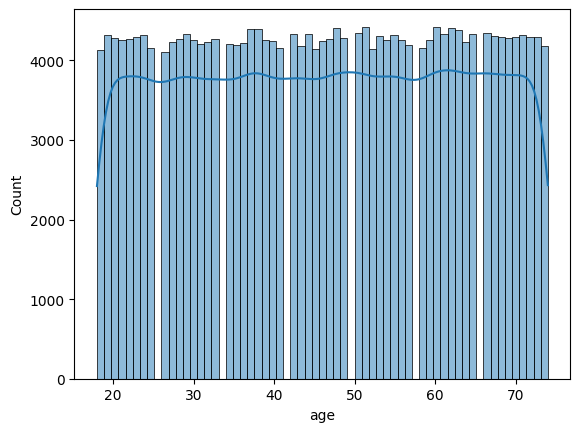

In [24]:
#normal distribution
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(dataset["age"], kde=True)

<Axes: xlabel='churn', ylabel='age'>

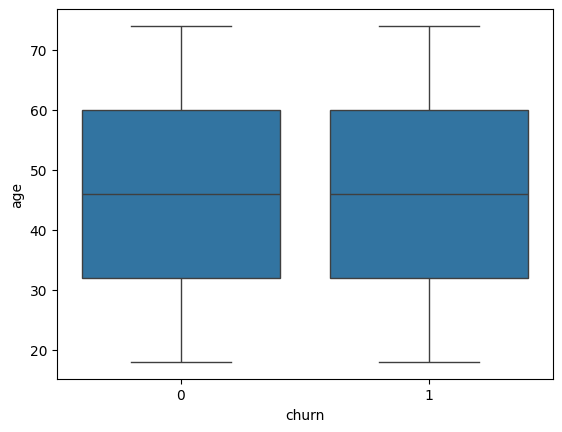

In [31]:
sns.boxplot(x='churn', y='age', data=dataset)

<Axes: xlabel='telecom_partner', ylabel='count'>

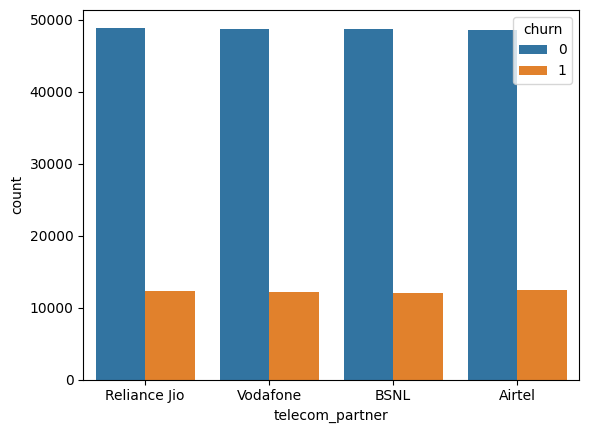

In [33]:
pd.crosstab(dataset['telecom_partner'], dataset['churn'], normalize='index') * 100
sns.countplot(x='telecom_partner', hue='churn', data=dataset)

<Axes: xlabel='gender', ylabel='count'>

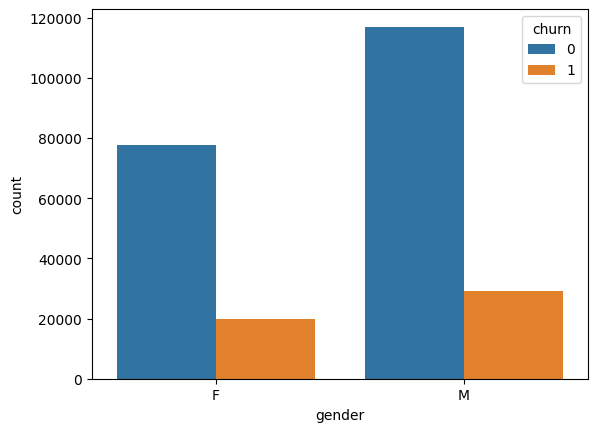

In [34]:
pd.crosstab(dataset['gender'], dataset['churn'], normalize='index') * 100
sns.countplot(x='gender', hue='churn', data=dataset)

<Axes: xlabel='city', ylabel='count'>

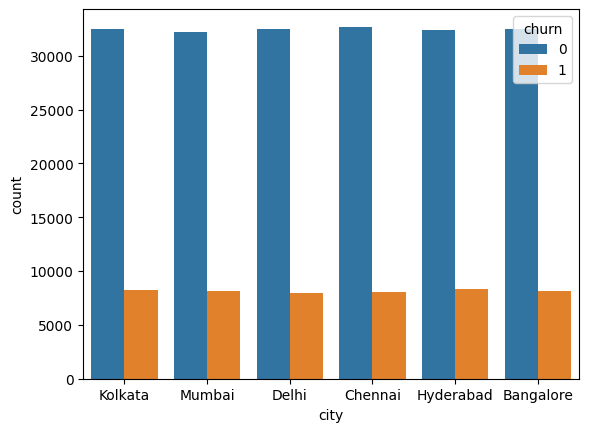

In [35]:
pd.crosstab(dataset['city'], dataset['churn'], normalize='index') * 100
sns.countplot(x='city', hue='churn', data=dataset)